In [24]:
import pandas as pd
import numpy as np

# EDA

In [25]:
df = pd.read_csv('car_price.csv')

In [26]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [27]:
df.shape

(72435, 10)

In [28]:
df.dtypes

model               str
year            float64
price           float64
transmission        str
mileage         float64
fuelType            str
tax             float64
mpg             float64
engineSize      float64
Make                str
dtype: object

In [29]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

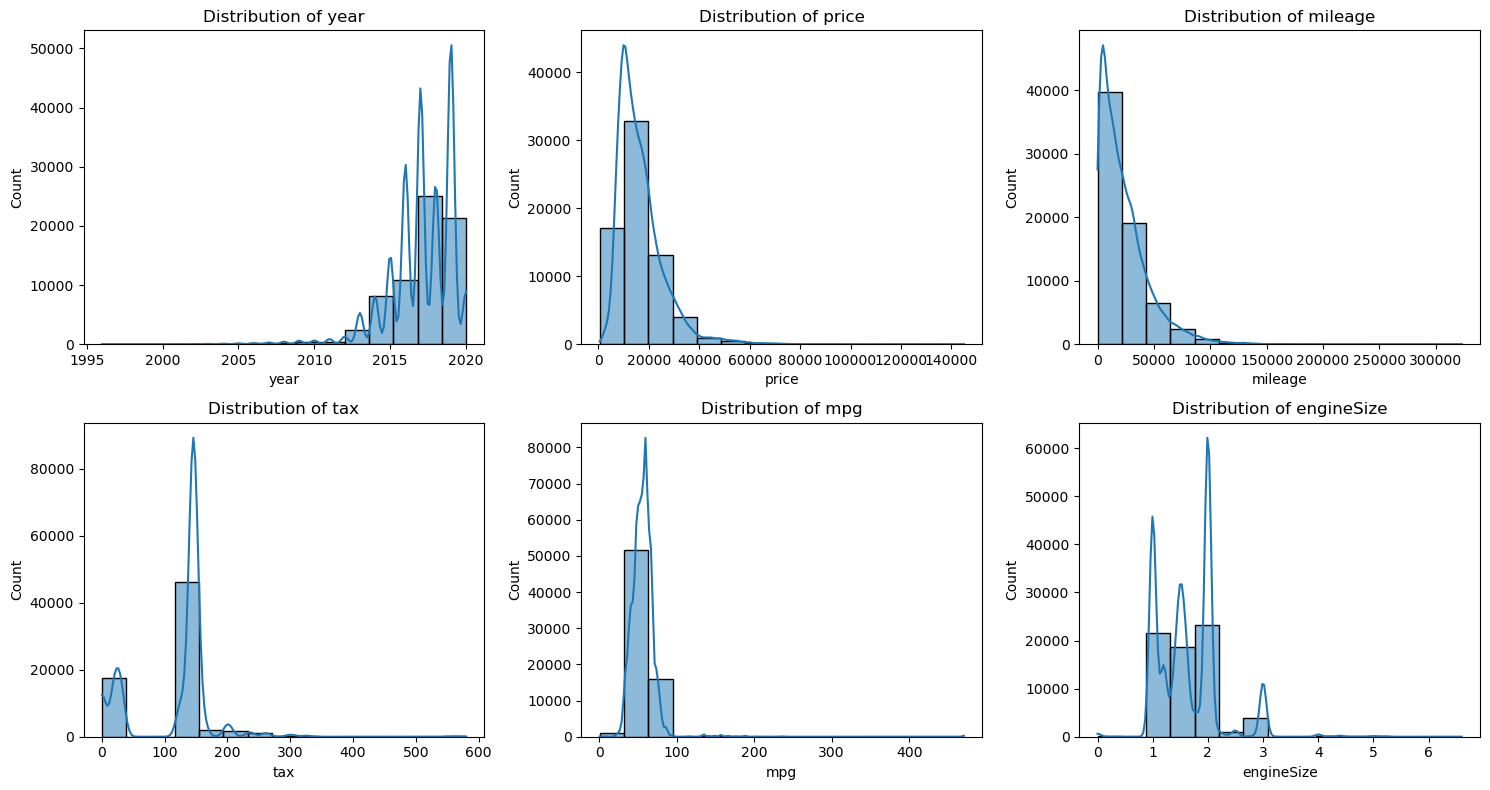

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = numeric_cols.columns
n = len(cols)

cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 4 * rows))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, bins=15, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<Axes: >

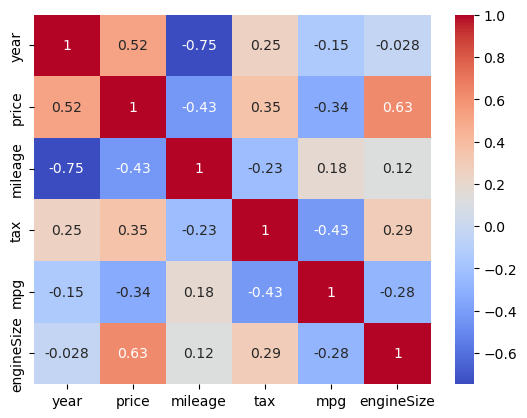

In [31]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

# Preprocessing

In [32]:
df.isnull().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

In [33]:
# Feature engineering

df['Car Age'] = 2026 - df['year']

def engine_group(x):
    if x < 1.6:
        return 'Small'
    elif x < 2.5:
        return 'Medium'
    else:
        return 'Large'


df['Engine Category'] = df['engineSize'].apply(engine_group)
df = df.drop(columns=['engineSize', 'year'])


In [ ]:
df_reg = df.dropna(subset=['price'])
df_reg = df_reg.drop(columns=['Make'])
X_reg = df_reg.drop('price', axis=1)
y_reg = df_reg['price']


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   model            68814 non-null  str    
 1   price            68814 non-null  float64
 2   transmission     68812 non-null  str    
 3   mileage          68813 non-null  float64
 4   fuelType         68813 non-null  str    
 5   tax              68814 non-null  float64
 6   mpg              68814 non-null  float64
 7   Make             68814 non-null  str    
 8   Car Age          68813 non-null  float64
 9   Engine Category  72435 non-null  str    
dtypes: float64(5), str(5)
memory usage: 5.5 MB


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    StandardScaler())

engine_categories = [['Small', 'Medium', 'Large']]
engine_pipline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OrdinalEncoder(categories=engine_categories)
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        ('log', log_pipeline, ['mileage']),
        ('num', numeric_transformer, ['tax','mpg','Car Age']),
        ('cat', categorical_transformer, ['model','transmission','fuelType']),
        ('engine', engine_pipline, ['Engine Category'])
    ]
)


# Regression Model

In [37]:
from sklearn.linear_model import LinearRegression

model = Pipeline(steps=[
    ('preprocessor', reg_preprocessor),
    ('regressor', LinearRegression())
])

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2,random_state=42 )

In [39]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [40]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_reg, y_reg, cv=kf)

print(f"R2 Scores: {scores}")
print(f"Average R2: {scores.mean():.4f}")

R2 Scores: [0.75641013 0.7610254  0.76447292 0.75519676 0.77110098]
Average R2: 0.7616


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2998.5437086819106
RMSE: 4552.795998416481
R2 Score: 0.7564101332586435


# Predicted vs Actual (Regression Plot)

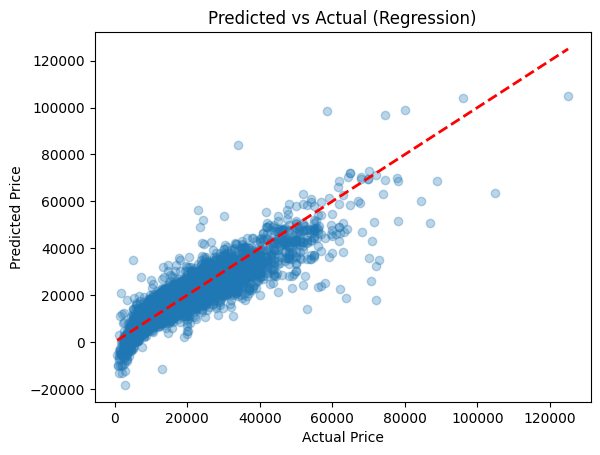

In [108]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual (Regression)')
plt.show()

# Task 3: Create Target Variables (Classification)

We define price thresholds based on quantiles (33% and 66%).
This ensures a balanced distribution across categories.


In [43]:
q1 = df['price'].quantile(0.33)
q2 = df['price'].quantile(0.66)
print(f"Thresholds: Cheap < {q1:.2f}, Moderate {q1:.2f} - {q2:.2f}, Expensive > {q2:.2f}")

def classify_price(price):
    if price < q1:
        return 'Cheap'
    elif price <= q2:
        return 'Moderate'
    else:
        return 'Expensive'

df['price_category'] = df['price'].apply(classify_price)


Thresholds: Cheap < 11450.00, Moderate 11450.00 - 17995.00, Expensive > 17995.00


# Task 5: KNN Classification


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 7}
              precision    recall  f1-score   support

           0       0.78      0.89      0.84      4592
           1       0.91      0.77      0.83      5391
           2       0.71      0.74      0.73      4504

    accuracy                           0.80     14487
   macro avg       0.80      0.80      0.80     14487
weighted avg       0.81      0.80      0.80     14487



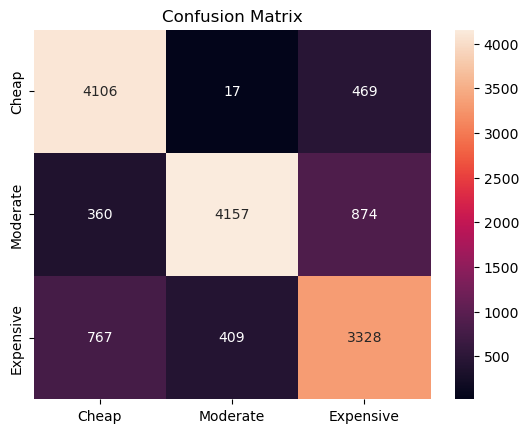

In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Prepare data for classification
df_class = df.dropna(subset=['price_category'])
X_class = df_class.drop(columns=['price', 'price_category', 'Make'])
y_class = df_class['price_category']

# Preprocessing for classification (using existing preprocessor structure)
# We can re-use the regression preprocessor for consistency as requested
knn_pipeline = Pipeline(steps=[
    ('preprocessor', reg_preprocessor),
    ('knn', KNeighborsClassifier(n_jobs=1))
])

# Grid Search
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__metric': ['euclidean', 'manhattan']
}

le = LabelEncoder()

# Transform your target labels from ['Cheap', 'Moderate', 'Expensive'] to [0, 1, 2]
y_class_encoded = le.fit_transform(y_class)

# Use the encoded y in your split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class_encoded, test_size=0.2, random_state=42
)

grid_search = GridSearchCV(knn_pipeline, param_grid, cv=3, verbose=1)
grid_search.fit(X_train_c, y_train_c)

print("Best Parameters:", grid_search.best_params_)
y_pred_c = grid_search.predict(X_test_c)

print(classification_report(y_test_c, y_pred_c))

# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Cheap', 'Moderate', 'Expensive'], yticklabels=['Cheap', 'Moderate', 'Expensive'])
plt.title('Confusion Matrix')
plt.show()


# Task 7: Visualization


### Price distribution histogram:

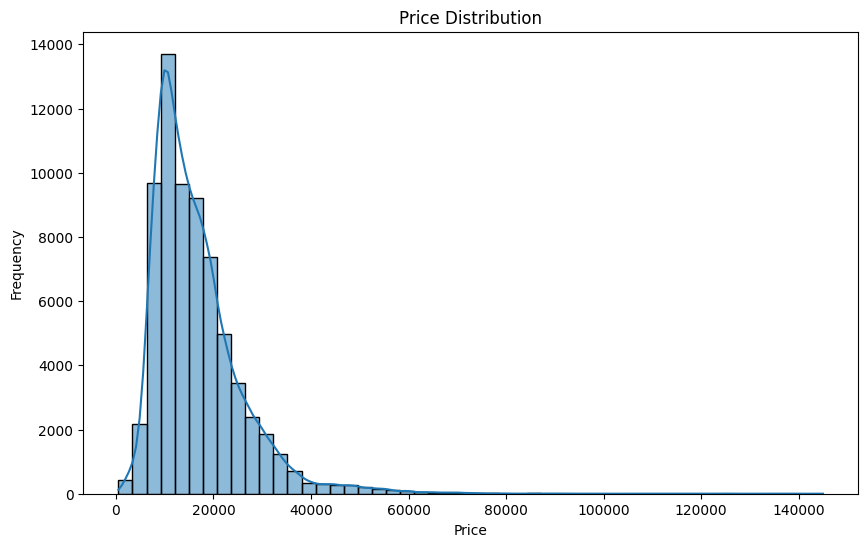

In [111]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


### Correlation heatmap:

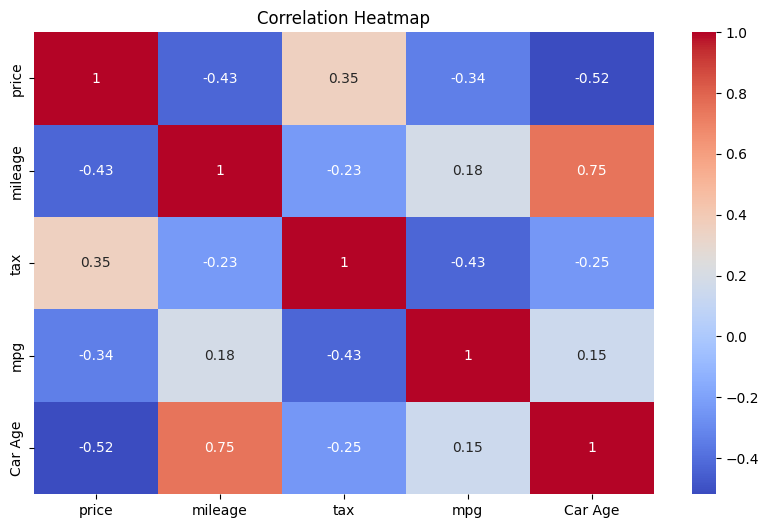

In [112]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Predicted vs. Actual scatter plot:

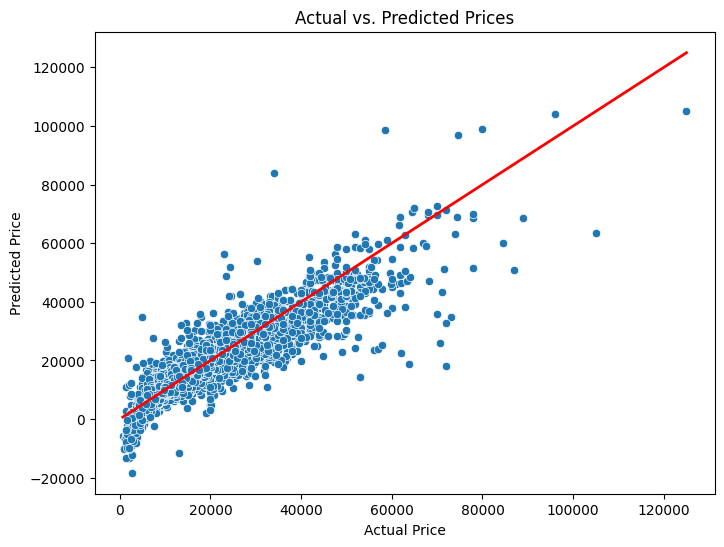

In [113]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted Prices')
plt.show()

### Confusion Matrix heatmap:

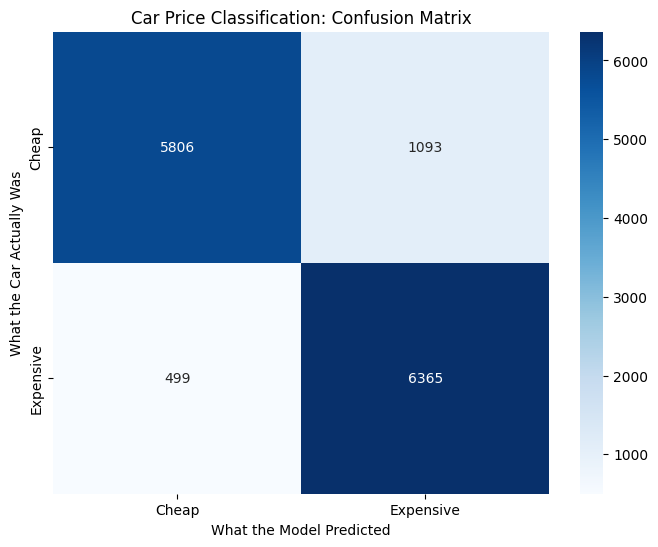

In [114]:
# Create categorical versions of your actual and predicted prices
threshold = df['price'].median()

y_test_class = (y_test > threshold).astype(int)
y_pred_class = (y_pred > threshold).astype(int)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_class, y_pred_class)

plt.figure(figsize=(8, 6))
labels = ['Cheap', 'Expensive']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.title('Car Price Classification: Confusion Matrix')
plt.xlabel('What the Model Predicted')
plt.ylabel('What the Car Actually Was')
plt.show()

## The Bonus 2 Plots:

### Price vs. Mileage:

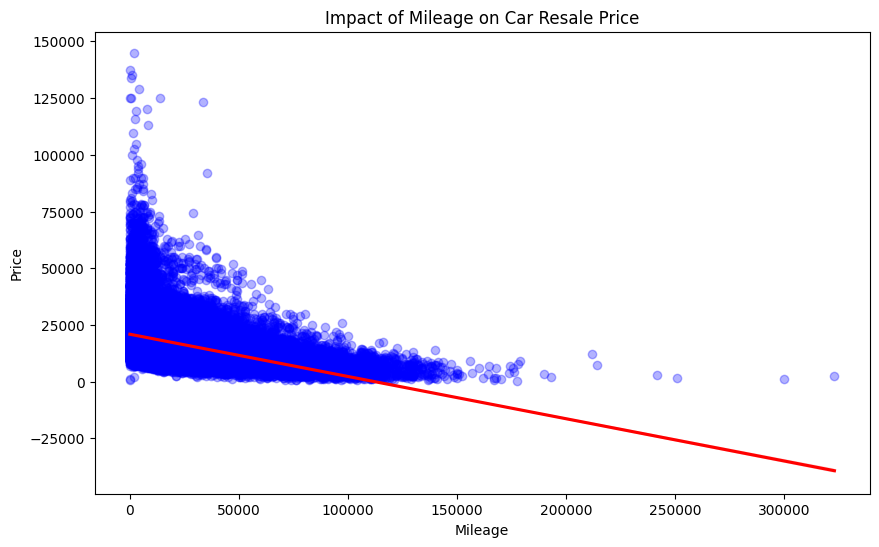

In [115]:
plt.figure(figsize=(10, 6))
sns.regplot(x='mileage', y='price', data=df, 
            scatter_kws={'alpha':0.3, 'color':'blue'}, 
            line_kws={'color':'red'})
plt.title('Impact of Mileage on Car Resale Price')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

# Explanation: 
# This plot shows the negative correlation between mileage and price. 
# As mileage increases, the resale value consistently drops, which 
# helps validate that our model is correctly prioritizing usage as a key feature.

### Price Distribution by Car Age:

C:\Users\Ahmed Hassan\AppData\Local\Temp\ipykernel_19872\3194977898.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Car Age', y='price', data=df, palette='magma')


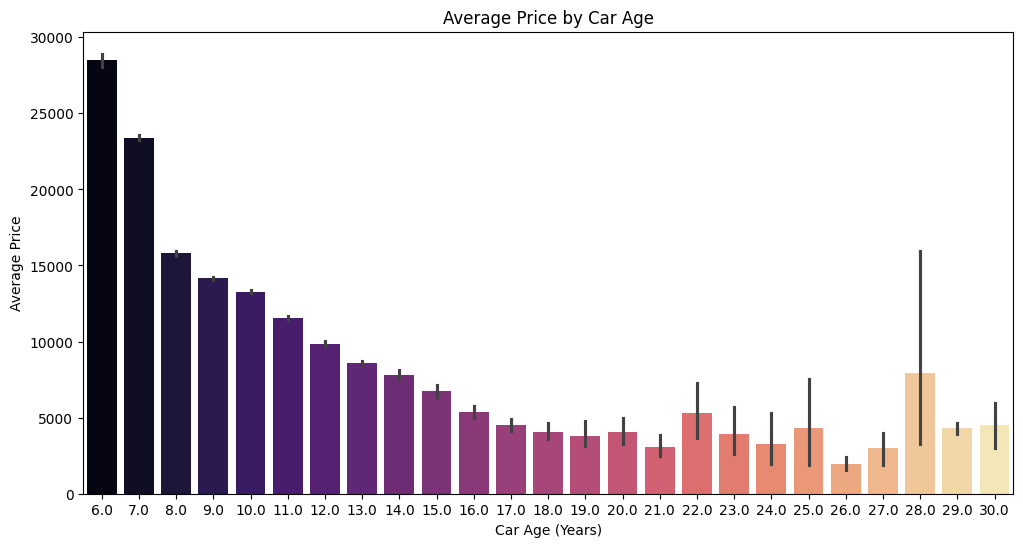

In [116]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Car Age', y='price', data=df, palette='magma')
plt.title('Average Price by Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Average Price')
plt.show()

# Explanation: 
# This bar plot illustrates the depreciation of cars over their lifespan. 
# It provides a clear visual of how significantly the value drops in the 
# first few years versus older age brackets, justifying our use of 
# Car Age in the regression model.

In [117]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict
y_pred_reg = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_reg)

print("=== Regression Performance ===")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

=== Regression Performance ===
MAE: 2477.3091409076765
MSE: 14325515.005304955
RMSE: 3784.90620825734
R2 Score: 0.8316500158040074


In [118]:
from sklearn.metrics import accuracy_score

print("=== Classification Performance ===")
print("Accuracy:", accuracy_score(y_test_c, y_pred_c))

=== Classification Performance ===
Accuracy: 0.8000966383654311


# Task 6

### Model Comparison

The classification model achieved an accuracy of ( 0.8000966383654311), while the regression model achieved an R² score of (0.8316500158040074).

Classification performed better in terms of simplicity and stability, while regression is better for precise numerical prediction.

### Is classification easier?
Yes, classification is easier because it predicts categories instead of exact numerical values, making it less sensitive to small variations in data.

### Does converting price lose information
Yes, converting price into categories results in loss of information because continuous values are grouped into discrete ranges.

### What happens if you remove the most correlated feature?
the model R2 drop from 0.83 to 0.75 

### running KNN without scaling
the accuracy increased from 8.0 to 8.2